In [1]:
import os
import glob
import sys
from datetime import datetime
import matplotlib.pyplot as plt
import random
import cv2
import numbers
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Union
from dataclasses import dataclass, asdict
import math
def count_params(model):
    """ Count model trainable parameters """
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Number of available cpu: {os.cpu_count()}')


Using device: cuda
Number of available cpu: 4


In [ ]:
!pip install einops
!pip install torchsummary
!pip install hdf5storage h5py
!pip install pytorch_msssim
!pip install tqdm
!pip install albumentations
!pip install torchmetrics[image]
!pip install fvcore
!pip install thop


In [4]:
# Standard library imports
import os
import json
import time
import random
import math
from dataclasses import dataclass
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional
# Third-party imports
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image, ImageOps
from tqdm.auto import tqdm
# PyTorch data utilities
from torch.utils.data import Dataset, DataLoader
# Global constants...
TARGET_CATEGORIES = [
    "10_dress",
    "8_skirt",
    "43_ruffle",
    "1_top__t_shirt__sweatshirt",
    "0_shirt__blouse",
    "4_jacket",
    "9_coat",
    "2_sweater",
    "3_cardigan",
    "5_vest",
    "6_pants",
    "7_shorts",
]
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


In [5]:
@dataclass
class PipelineConfig:
    """Configuration object for paired sketch-real samples."""
    real_root: str
    sketch_roots: Dict[str, str]
    categories: Tuple[str, ...] = tuple(TARGET_CATEGORIES)
    sketch_ratios: Dict[str, float] = None
    seed: int = 42
    def __post_init__(self):
        if self.sketch_ratios is None:
            self.sketch_ratios = {"hed": 0.5, "pencil": 0.3, "canny": 0.2}
        ratio_sum = sum(self.sketch_ratios.values())
        if not math.isclose(ratio_sum, 1.0, rel_tol=1e-6):
            raise ValueError(f"Sketch ratios must sum to 1.0, got {ratio_sum}")


In [6]:
def smart_pad_and_resize(img: Image.Image, target_size: int = 256) -> Image.Image:
    """Pad an image to a square canvas, then resize to the target resolution."""
    w, h = img.size
    max_side = max(w, h)
    # Ensure the square canvas is at least target_size to avoid up/downscale artifacts.
    canvas_side = max(max_side, target_size)
    pad_left = (canvas_side - w) // 2
    pad_top = (canvas_side - h) // 2
    pad_right = canvas_side - w - pad_left
    pad_bottom = canvas_side - h - pad_top
    # Use white padding to match common sketch/clean-background assumptions.
    img_padded = ImageOps.expand(
        img,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=(255, 255, 255),
    )
    if img_padded.size != (target_size, target_size):
        img_padded = img_padded.resize((target_size, target_size), Image.BICUBIC)
    return img_padded
def list_category_images(root: Path, category: str) -> Dict[str, Path]:
    """Return a mapping from filename stem to image path for one category."""
    category_dir = root / category
    if not category_dir.exists():
        return {}
    return {
        p.stem: p
        for p in category_dir.iterdir()
        if p.suffix.lower() in IMG_EXTENSIONS
    }


In [7]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from pathlib import Path
import json
import math
import random
import time
from collections import Counter



def build_gan_pairs(config: PipelineConfig) -> Tuple[List[dict], dict]:
    """Build paired sketch-real samples."""
    print("\n[1/3] Scanning categories, matching real-sketch files, ...")
    start_time = time.time()

    real_root = Path(config.real_root)
    sketch_roots = {k: Path(v) for k, v in config.sketch_roots.items()}
    rows: List[dict] = []
    skipped_no_sketch = 0

    for category in tqdm(config.categories, desc="Scanning categories"):
        real_images = list_category_images(real_root, category)
        if not real_images:
            continue

        sketch_index = {
            method: list_category_images(root, category)
            for method, root in sketch_roots.items()
        }

        for stem, real_path in real_images.items():
            candidates = {
                method: sketch_index[method][stem]
                for method in sketch_index
                if stem in sketch_index[method]
            }
            if not candidates:
                skipped_no_sketch += 1
                continue
            rows.append(
                {
                    "category": category,
                    "filename_stem": stem,
                    "real_path": str(real_path),
                    "sketch_candidates": candidates,
                    "available_methods": sorted(candidates.keys()),
                }
            )

    print(f"Matched {len(rows)} pairs. Skipped {skipped_no_sketch} without sketches.")
    print("\n[2/3] Assigning sketch methods using ratio targets...")

    rng = random.Random(config.seed)
    total_found = len(rows)
    methods = list(config.sketch_ratios.keys())
    targets = {m: int(total_found * config.sketch_ratios[m]) for m in methods}
    remaining = dict(targets)

    indices = list(range(total_found))
    rng.shuffle(indices)

    for idx in tqdm(indices, desc="Assigning sketch method"):
        row = rows[idx]
        available = row["available_methods"]
        preferred = [m for m in available if remaining.get(m, 0) > 0]
        method = rng.choice(preferred) if preferred else rng.choice(available)

        row["sketch_method"] = method
        row["sketch_path"] = str(row["sketch_candidates"][method])
        if method in remaining:
            remaining[method] -= 1

    final_rows = [
        {
            "category": r["category"],
            "filename_stem": r["filename_stem"],
            "real_path": r["real_path"],
            "sketch_path": r["sketch_path"],
            "sketch_method": r["sketch_method"],
        }
        for r in rows
    ]

    duration = time.time() - start_time
    print(f"Data preparation completed in {duration:.2f}s.")

    summary = {
        "num_pairs": len(final_rows),
        "sketch_method_counts": dict(Counter(r["sketch_method"] for r in final_rows)),
        "skipped_no_sketch": skipped_no_sketch,
    }
    return final_rows, summary

In [8]:
# Cell 5
import os
from typing import List, Tuple, Optional
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class SketchToRealGANDataset(Dataset):
    """PyTorch dataset that loads paired sketch-real images ."""

    def __init__(
        self,
        rows: List[dict],
        image_size: int = 256,
        apply_augmentation: bool = False,
        flip_prob: float = 0.5,
        crop_scale: Tuple[float, float] = (0.9, 1.0),
        max_translate_ratio: float = 0.08,
        max_rotation_deg: float = 10.0,
        scale_range: Tuple[float, float] = (0.95, 1.05),
        # Thêm các tham số cho việc làm đứt nét Sketch
        sketch_degrade_prob: float = 0.7,
        degrade_holes_range: Tuple[int, int] = (5, 20),
        degrade_size_range: Tuple[int, int] = (10, 40),
    ):
        self.rows = rows
        self.image_size = image_size
        self.apply_augmentation = apply_augmentation
        
        # --- 1. SPATIAL AUGMENTATION (Áp dụng chung cho cả Real và Sketch để giữ align) ---
        max_shift_percent = max_translate_ratio * 100.0
        self._spatial_augment = A.Compose(
            [
                A.HorizontalFlip(p=flip_prob),
                A.RandomResizedCrop(
                    size=(self.image_size, self.image_size),
                    scale=crop_scale,
                    ratio=(1.0, 1.0),
                    interpolation=cv2.INTER_CUBIC,
                    p=1.0,
                ),
                A.Affine(
                    scale=scale_range,
                    translate_percent={"x": (-max_shift_percent / 100.0, max_shift_percent / 100.0), "y": (-max_shift_percent / 100.0, max_shift_percent / 100.0)},
                    rotate=(-max_rotation_deg, max_rotation_deg),
                    interpolation=cv2.INTER_CUBIC,
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=(255, 255, 255),
                    p=1.0,
                ),
            ],
            additional_targets={"real": "image"},
        )

        # --- 2. SKETCH DEGRADATION (Chỉ áp dụng cho Sketch để ép model học nội suy) ---
        self._sketch_only_augment = A.Compose(
            [
                # Làm đứt nét bằng cách xóa ngẫu nhiên các ô vuông (tô màu trắng)
                A.CoarseDropout(
                    max_holes=degrade_holes_range[1],
                    min_holes=degrade_holes_range[0],
                    max_height=degrade_size_range[1],
                    max_width=degrade_size_range[1],
                    min_height=degrade_size_range[0],
                    min_width=degrade_size_range[0],
                    fill=(255, 255, 255), 
                    p=sketch_degrade_prob
                ),
                # Làm méo/xô lệch nét vẽ nhẹ
                A.ElasticTransform(
                    alpha=300, sigma=10,
                    interpolation=cv2.INTER_CUBIC,
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=(255, 255, 255), 
                    p=sketch_degrade_prob * 0.7
                ),
            ]
        )

    def _load_img(self, path: str) -> np.ndarray:
        with Image.open(path) as src_img:
            img = src_img.convert("RGB")
        # Giả định hàm smart_pad_and_resize đã được định nghĩa ở Cell 3
        img = smart_pad_and_resize(img, target_size=self.image_size)
        return np.asarray(img, dtype=np.uint8)

    def _apply_spatial_augment_pair(
        self,
        sketch_img: np.ndarray,
        real_img: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray]:
        transformed = self._spatial_augment(image=sketch_img, real=real_img)
        return transformed["image"], transformed["real"]

    def _to_tensor(self, img: np.ndarray) -> torch.Tensor:
        arr = img.astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        sketch_img = self._load_img(row["sketch_path"])
        real_img = self._load_img(row["real_path"])
        
        if self.apply_augmentation:
            # Bước 1: Augment không gian cho cả 2 ảnh để giữ sự đồng nhất
            sketch_img, real_img = self._apply_spatial_augment_pair(sketch_img, real_img)
            
            # Bước 2: Chỉ làm hỏng (degrade) ảnh Sketch
            sketch_img = self._sketch_only_augment(image=sketch_img)["image"]

        return {
            "sketch": self._to_tensor(sketch_img),
            "real": self._to_tensor(real_img),
            "filename_stem": row["filename_stem"],
        }


def build_gan_dataloader(
    rows: List[dict],
    batch_size: int = 16,
    image_size: int = 256,
    shuffle: bool = True,
    num_workers: Optional[int] = None,
    apply_augmentation: bool = False,
    sketch_degrade_prob: float = 0.7, 
) -> DataLoader:
    """Build a DataLoader from paired metadata rows."""
    if num_workers is None:
        num_workers = 0 if os.name == "nt" else max(1, min(4, (os.cpu_count() or 2) // 2))

    dataset = SketchToRealGANDataset(
        rows=rows,
        image_size=image_size,
        apply_augmentation=apply_augmentation,
        sketch_degrade_prob=sketch_degrade_prob,
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )


In [9]:
print("Starting data pipeline for EVALUATION...")
PIPE_CFG = PipelineConfig(
    real_root="/kaggle/input/datasets/vunhuduc/val-fashion/(3)_images_filtered",
    sketch_roots={
        "pencil": "/kaggle/input/datasets/vunhuduc/val-sketch-pencil/(4)_sketch_pencil",
    },
    sketch_ratios={"pencil": 1.0},
)
eval_rows, eval_summary = build_gan_pairs(PIPE_CFG)
print("\n" + "=" * 30)
print("EVALUATION PIPELINE SUMMARY:")
print(f"- Total paired samples: {eval_summary['num_pairs']}")
for method, count in eval_summary["sketch_method_counts"].items():
    print(f"  + {method}: {count} samples")
print("=" * 30)
eval_loader = build_gan_dataloader(
    rows=eval_rows,
    batch_size=16,
    image_size=256,
    shuffle=False,  # Don't shuffle for eval
    apply_augmentation=False, # No augmentation for evaluation
)
print(f"DataLoader ready. Total batches: {len(eval_loader)}")


Starting data pipeline for EVALUATION...

[1/3] Scanning categories, matching real-sketch files, ...


Scanning categories:   0%|          | 0/12 [00:00<?, ?it/s]

Matched 1708 pairs. Skipped 0 without sketches.

[2/3] Assigning sketch methods using ratio targets...


Assigning sketch method:   0%|          | 0/1708 [00:00<?, ?it/s]

Data preparation completed in 0.32s.

EVALUATION PIPELINE SUMMARY:
- Total paired samples: 1708
  + pencil: 1708 samples
DataLoader ready. Total batches: 107


/tmp/ipykernel_59/2108878725.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


# CycleGAN Architecture Components

This section contains the CycleGAN building blocks: ResNet Generator, PatchGAN Discriminator, and GANLoss.

In [ ]:
import torch
import torch.nn as nn
from torch.nn import init
import functools
from torch.optim import lr_scheduler


###############################################################################
# Helper Functions
###############################################################################


class Identity(nn.Module):
    def forward(self, x):
        return x


def get_norm_layer(norm_type="instance"):
    """Return a normalization layer

    Parameters:
        norm_type (str) -- the name of the normalization layer: batch | instance | none

    For BatchNorm, we use learnable affine parameters and track running statistics (mean/stddev).
    For InstanceNorm, we do not use learnable affine parameters. We do not track running statistics.
    """
    if norm_type == "batch":
        norm_layer = functools.partial(nn.BatchNorm2d, affine=True, track_running_stats=True)
    elif norm_type == "syncbatch":
        norm_layer = functools.partial(nn.SyncBatchNorm, affine=True, track_running_stats=True)
    elif norm_type == "instance":
        norm_layer = functools.partial(nn.InstanceNorm2d, affine=False, track_running_stats=False)
    elif norm_type == "none":

        def norm_layer(x):
            return Identity()

    else:
        raise NotImplementedError("normalization layer [%s] is not found" % norm_type)
    return norm_layer


def get_scheduler(optimizer, opt):
    """Return a learning rate scheduler

    Parameters:
        optimizer          -- the optimizer of the network
        opt (option class) -- stores all the experiment flags; needs to be a subclass of BaseOptions．
                              opt.lr_policy is the name of learning rate policy: linear | step | plateau | cosine

    For 'linear', we keep the same learning rate for the first <opt.n_epochs> epochs
    and linearly decay the rate to zero over the next <opt.n_epochs_decay> epochs.
    For other schedulers (step, plateau, and cosine), we use the default PyTorch schedulers.
    See https://pytorch.org/docs/stable/optim.html for more details.
    """
    if opt.lr_policy == "linear":

        def lambda_rule(epoch):
            lr_l = 1.0 - max(0, epoch + opt.epoch_count - opt.n_epochs) / float(opt.n_epochs_decay + 1)
            return lr_l

        scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_rule)
    elif opt.lr_policy == "step":
        scheduler = lr_scheduler.StepLR(optimizer, step_size=opt.lr_decay_iters, gamma=0.1)
    elif opt.lr_policy == "plateau":
        scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.2, threshold=0.01, patience=5)
    elif opt.lr_policy == "cosine":
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=opt.n_epochs, eta_min=0)
    else:
        return NotImplementedError("learning rate policy [%s] is not implemented", opt.lr_policy)
    return scheduler


def init_weights(net, init_type="normal", init_gain=0.02):
    """Initialize network weights.

    Parameters:
        net (network)   -- network to be initialized
        init_type (str) -- the name of an initialization method: normal | xavier | kaiming | orthogonal
        init_gain (float)    -- scaling factor for normal, xavier and orthogonal.

    We use 'normal' in the original pix2pix and CycleGAN paper. But xavier and kaiming might
    work better for some applications. Feel free to try yourself.
    """

    def init_func(m):  # define the initialization function
        classname = m.__class__.__name__
        if hasattr(m, "weight") and (classname.find("Conv") != -1 or classname.find("Linear") != -1):
            if init_type == "normal":
                init.normal_(m.weight.data, 0.0, init_gain)
            elif init_type == "xavier":
                init.xavier_normal_(m.weight.data, gain=init_gain)
            elif init_type == "kaiming":
                init.kaiming_normal_(m.weight.data, a=0, mode="fan_in")
            elif init_type == "orthogonal":
                init.orthogonal_(m.weight.data, gain=init_gain)
            else:
                raise NotImplementedError("initialization method [%s] is not implemented" % init_type)
            if hasattr(m, "bias") and m.bias is not None:
                init.constant_(m.bias.data, 0.0)
        elif classname.find("BatchNorm2d") != -1:  # BatchNorm Layer's weight is not a matrix; only normal distribution applies.
            init.normal_(m.weight.data, 1.0, init_gain)
            init.constant_(m.bias.data, 0.0)

    print("initialize network with %s" % init_type)
    net.apply(init_func)  # apply the initialization function <init_func>


def init_net(net, init_type="normal", init_gain=0.02):
    """Initialize a network: 1. register CPU/GPU device; 2. initialize the network weights
    Parameters:
        net (network)      -- the network to be initialized
        init_type (str)    -- the name of an initialization method: normal | xavier | kaiming | orthogonal
        gain (float)       -- scaling factor for normal, xavier and orthogonal.

    Return an initialized network.
    """
    import os

    if torch.cuda.is_available():
        if "LOCAL_RANK" in os.environ:
            local_rank = int(os.environ["LOCAL_RANK"])
            net.to(local_rank)
            print(f"Initialized with device cuda:{local_rank}")
        else:
            net.to(0)
            print("Initialized with device cuda:0")
    init_weights(net, init_type, init_gain=init_gain)
    return net


def define_G(input_nc, output_nc, ngf, netG, norm="batch", use_dropout=False, init_type="normal", init_gain=0.02):
    """Create a generator

    Parameters:
        input_nc (int) -- the number of channels in input images
        output_nc (int) -- the number of channels in output images
        ngf (int) -- the number of filters in the last conv layer
        netG (str) -- the architecture's name: resnet_9blocks | resnet_6blocks | unet_128 | resnet_9blocks
        norm (str) -- the name of normalization layers used in the network: batch | instance | none
        use_dropout (bool) -- if use dropout layers.
        init_type (str)    -- the name of our initialization method.
        init_gain (float)  -- scaling factor for normal, xavier and orthogonal.

    Returns a generator
    """
    net = None
    norm_layer = get_norm_layer(norm_type=norm)

    if netG == "resnet_9blocks":
        net = ResnetGenerator(input_nc, output_nc, ngf, norm_layer=norm_layer, use_dropout=use_dropout, n_blocks=9)
    elif netG == "resnet_6blocks":
        net = ResnetGenerator(input_nc, output_nc, ngf, norm_layer=norm_layer, use_dropout=use_dropout, n_blocks=6)
    elif netG == "unet_128":
        net = UnetGenerator(input_nc, output_nc, 7, ngf, norm_layer=norm_layer, use_dropout=use_dropout)
    elif netG == "resnet_9blocks":
        net = UnetGenerator(input_nc, output_nc, 8, ngf, norm_layer=norm_layer, use_dropout=use_dropout)
    else:
        raise NotImplementedError("Generator model name [%s] is not recognized" % netG)
    return net


def define_D(input_nc, ndf, netD, n_layers_D=3, norm="batch", init_type="normal", init_gain=0.02):
    """Create a discriminator

    Parameters:
        input_nc (int)     -- the number of channels in input images
        ndf (int)          -- the number of filters in the first conv layer
        netD (str)         -- the architecture's name: basic | n_layers | pixel
        n_layers_D (int)   -- the number of conv layers in the discriminator; effective when netD=='n_layers'
        norm (str)         -- the type of normalization layers used in the network.
        init_type (str)    -- the name of the initialization method.
        init_gain (float)  -- scaling factor for normal, xavier and orthogonal.

    Returns a discriminator

    Our current implementation provides three types of discriminators:
        [basic]: 'PatchGAN' classifier described in the original pix2pix paper.
        It can classify whether 70×70 overlapping patches are real or fake.
        Such a patch-level discriminator architecture has fewer parameters
        than a full-image discriminator and can work on arbitrarily-sized images
        in a fully convolutional fashion.

        [n_layers]: With this mode, you can specify the number of conv layers in the discriminator
        with the parameter <n_layers_D> (default=3 as used in [basic] (PatchGAN).)

        [pixel]: 1x1 PixelGAN discriminator can classify whether a pixel is real or not.
        It encourages greater color diversity but has no effect on spatial statistics.

    The discriminator has been initialized by <init_net>. It uses Leakly RELU for non-linearity.
    """
    net = None
    norm_layer = get_norm_layer(norm_type=norm)

    if netD == "basic":  # default PatchGAN classifier
        net = NLayerDiscriminator(input_nc, ndf, n_layers=3, norm_layer=norm_layer)
    elif netD == "n_layers":  # more options
        net = NLayerDiscriminator(input_nc, ndf, n_layers_D, norm_layer=norm_layer)
    elif netD == "pixel":  # classify if each pixel is real or fake
        net = PixelDiscriminator(input_nc, ndf, norm_layer=norm_layer)
    else:
        raise NotImplementedError("Discriminator model name [%s] is not recognized" % netD)
    return net


##############################################################################
# Classes
##############################################################################
class GANLoss(nn.Module):
    """Define different GAN objectives.

    The GANLoss class abstracts away the need to create the target label tensor
    that has the same size as the input.
    """

    def __init__(self, gan_mode, target_real_label=1.0, target_fake_label=0.0):
        """Initialize the GANLoss class.

        Parameters:
            gan_mode (str) - - the type of GAN objective. It currently supports vanilla, lsgan, and wgangp.
            target_real_label (bool) - - label for a real image
            target_fake_label (bool) - - label of a fake image

        Note: Do not use sigmoid as the last layer of Discriminator.
        LSGAN needs no sigmoid. vanilla GANs will handle it with BCEWithLogitsLoss.
        """
        super(GANLoss, self).__init__()
        self.register_buffer("real_label", torch.tensor(target_real_label))
        self.register_buffer("fake_label", torch.tensor(target_fake_label))
        self.gan_mode = gan_mode
        if gan_mode == "lsgan":
            self.loss = nn.MSELoss()
        elif gan_mode == "vanilla":
            self.loss = nn.BCEWithLogitsLoss()
        elif gan_mode in ["wgangp"]:
            self.loss = None
        else:
            raise NotImplementedError("gan mode %s not implemented" % gan_mode)

    def get_target_tensor(self, prediction, target_is_real):
        """Create label tensors with the same size as the input.

        Parameters:
            prediction (tensor) - - tpyically the prediction from a discriminator
            target_is_real (bool) - - if the ground truth label is for real images or fake images

        Returns:
            A label tensor filled with ground truth label, and with the size of the input
        """

        if target_is_real:
            target_tensor = self.real_label
        else:
            target_tensor = self.fake_label
        return target_tensor.expand_as(prediction)

    def __call__(self, prediction, target_is_real):
        """Calculate loss given Discriminator's output and grount truth labels.

        Parameters:
            prediction (tensor) - - tpyically the prediction output from a discriminator
            target_is_real (bool) - - if the ground truth label is for real images or fake images

        Returns:
            the calculated loss.
        """
        if self.gan_mode in ["lsgan", "vanilla"]:
            target_tensor = self.get_target_tensor(prediction, target_is_real)
            loss = self.loss(prediction, target_tensor)
        elif self.gan_mode == "wgangp":
            if target_is_real:
                loss = -prediction.mean()
            else:
                loss = prediction.mean()
        return loss


def cal_gradient_penalty(netD, real_data, fake_data, device, type="mixed", constant=1.0, lambda_gp=10.0):
    """Calculate the gradient penalty loss, used in WGAN-GP paper https://arxiv.org/abs/1704.00028

    Arguments:
        netD (network)              -- discriminator network
        real_data (tensor array)    -- real images
        fake_data (tensor array)    -- generated images from the generator
        device (str)                -- GPU / CPU
        type (str)                  -- if we mix real and fake data or not [real | fake | mixed].
        constant (float)            -- the constant used in formula ( ||gradient||_2 - constant)^2
        lambda_gp (float)           -- weight for this loss

    Returns the gradient penalty loss
    """
    if lambda_gp > 0.0:
        if type == "real":  # either use real images, fake images, or a linear interpolation of two.
            interpolatesv = real_data
        elif type == "fake":
            interpolatesv = fake_data
        elif type == "mixed":
            alpha = torch.rand(real_data.shape[0], 1, device=device)
            alpha = alpha.expand(real_data.shape[0], real_data.nelement() // real_data.shape[0]).contiguous().view(*real_data.shape)
            interpolatesv = alpha * real_data + ((1 - alpha) * fake_data)
        else:
            raise NotImplementedError(f"{type} not implemented")
        interpolatesv.requires_grad_(True)
        disc_interpolates = netD(interpolatesv)
        gradients = torch.autograd.grad(outputs=disc_interpolates, inputs=interpolatesv, grad_outputs=torch.ones(disc_interpolates.size()).to(device), create_graph=True, retain_graph=True, only_inputs=True)
        gradients = gradients[0].view(real_data.size(0), -1)  # flat the data
        gradient_penalty = (((gradients + 1e-16).norm(2, dim=1) - constant) ** 2).mean() * lambda_gp  # added eps
        return gradient_penalty, gradients
    else:
        return 0.0, None


class ResnetGenerator(nn.Module):
    """Resnet-based generator that consists of Resnet blocks between a few downsampling/upsampling operations.

    We adapt Torch code and idea from Justin Johnson's neural style transfer project(https://github.com/jcjohnson/fast-neural-style)
    """

    def __init__(self, input_nc, output_nc, ngf=64, norm_layer=nn.BatchNorm2d, use_dropout=False, n_blocks=6, padding_type="reflect"):
        """Construct a Resnet-based generator

        Parameters:
            input_nc (int)      -- the number of channels in input images
            output_nc (int)     -- the number of channels in output images
            ngf (int)           -- the number of filters in the last conv layer
            norm_layer          -- normalization layer
            use_dropout (bool)  -- if use dropout layers
            n_blocks (int)      -- the number of ResNet blocks
            padding_type (str)  -- the name of padding layer in conv layers: reflect | replicate | zero
        """
        assert n_blocks >= 0
        super(ResnetGenerator, self).__init__()
        if type(norm_layer) == functools.partial:
            use_bias = norm_layer.func == nn.InstanceNorm2d
        else:
            use_bias = norm_layer == nn.InstanceNorm2d

        model = [nn.ReflectionPad2d(3), nn.Conv2d(input_nc, ngf, kernel_size=7, padding=0, bias=use_bias), norm_layer(ngf), nn.ReLU(True)]

        n_downsampling = 2
        for i in range(n_downsampling):  # add downsampling layers
            mult = 2**i
            model += [nn.Conv2d(ngf * mult, ngf * mult * 2, kernel_size=3, stride=2, padding=1, bias=use_bias), norm_layer(ngf * mult * 2), nn.ReLU(True)]

        mult = 2**n_downsampling
        for i in range(n_blocks):  # add ResNet blocks

            model += [ResnetBlock(ngf * mult, padding_type=padding_type, norm_layer=norm_layer, use_dropout=use_dropout, use_bias=use_bias)]

        for i in range(n_downsampling):  # add upsampling layers
            mult = 2 ** (n_downsampling - i)
            model += [nn.ConvTranspose2d(ngf * mult, int(ngf * mult / 2), kernel_size=3, stride=2, padding=1, output_padding=1, bias=use_bias), norm_layer(int(ngf * mult / 2)), nn.ReLU(True)]
        model += [nn.ReflectionPad2d(3)]
        model += [nn.Conv2d(ngf, output_nc, kernel_size=7, padding=0)]
        model += [nn.Tanh()]

        self.model = nn.Sequential(*model)

    def forward(self, input):
        """Standard forward"""
        return self.model(input)


class ResnetBlock(nn.Module):
    """Define a Resnet block"""

    def __init__(self, dim, padding_type, norm_layer, use_dropout, use_bias):
        """Initialize the Resnet block

        A resnet block is a conv block with skip connections
        We construct a conv block with build_conv_block function,
        and implement skip connections in <forward> function.
        Original Resnet paper: https://arxiv.org/pdf/1512.03385.pdf
        """
        super(ResnetBlock, self).__init__()
        self.conv_block = self.build_conv_block(dim, padding_type, norm_layer, use_dropout, use_bias)

    def build_conv_block(self, dim, padding_type, norm_layer, use_dropout, use_bias):
        """Construct a convolutional block.

        Parameters:
            dim (int)           -- the number of channels in the conv layer.
            padding_type (str)  -- the name of padding layer: reflect | replicate | zero
            norm_layer          -- normalization layer
            use_dropout (bool)  -- if use dropout layers.
            use_bias (bool)     -- if the conv layer uses bias or not

        Returns a conv block (with a conv layer, a normalization layer, and a non-linearity layer (ReLU))
        """
        conv_block = []
        p = 0
        if padding_type == "reflect":
            conv_block += [nn.ReflectionPad2d(1)]
        elif padding_type == "replicate":
            conv_block += [nn.ReplicationPad2d(1)]
        elif padding_type == "zero":
            p = 1
        else:
            raise NotImplementedError("padding [%s] is not implemented" % padding_type)

        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=p, bias=use_bias), norm_layer(dim), nn.ReLU(True)]
        if use_dropout:
            conv_block += [nn.Dropout(0.5)]

        p = 0
        if padding_type == "reflect":
            conv_block += [nn.ReflectionPad2d(1)]
        elif padding_type == "replicate":
            conv_block += [nn.ReplicationPad2d(1)]
        elif padding_type == "zero":
            p = 1
        else:
            raise NotImplementedError("padding [%s] is not implemented" % padding_type)
        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=p, bias=use_bias), norm_layer(dim)]

        return nn.Sequential(*conv_block)

    def forward(self, x):
        """Forward function (with skip connections)"""
        out = x + self.conv_block(x)  # add skip connections
        return out


class UnetGenerator(nn.Module):
    """Create a Unet-based generator"""

    def __init__(self, input_nc, output_nc, num_downs, ngf=64, norm_layer=nn.BatchNorm2d, use_dropout=False):
        """Construct a Unet generator
        Parameters:
            input_nc (int)  -- the number of channels in input images
            output_nc (int) -- the number of channels in output images
            num_downs (int) -- the number of downsamplings in UNet. For example, # if |num_downs| == 7,
                                image of size 128x128 will become of size 1x1 # at the bottleneck
            ngf (int)       -- the number of filters in the last conv layer
            norm_layer      -- normalization layer

        We construct the U-Net from the innermost layer to the outermost layer.
        It is a recursive process.
        """
        super(UnetGenerator, self).__init__()
        # construct unet structure
        unet_block = UnetSkipConnectionBlock(ngf * 8, ngf * 8, input_nc=None, submodule=None, norm_layer=norm_layer, innermost=True)  # add the innermost layer
        for i in range(num_downs - 5):  # add intermediate layers with ngf * 8 filters
            unet_block = UnetSkipConnectionBlock(ngf * 8, ngf * 8, input_nc=None, submodule=unet_block, norm_layer=norm_layer, use_dropout=use_dropout)
        # gradually reduce the number of filters from ngf * 8 to ngf
        unet_block = UnetSkipConnectionBlock(ngf * 4, ngf * 8, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        unet_block = UnetSkipConnectionBlock(ngf * 2, ngf * 4, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        unet_block = UnetSkipConnectionBlock(ngf, ngf * 2, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        self.model = UnetSkipConnectionBlock(output_nc, ngf, input_nc=input_nc, submodule=unet_block, outermost=True, norm_layer=norm_layer)  # add the outermost layer

    def forward(self, input):
        """Standard forward"""
        return self.model(input)


class UnetSkipConnectionBlock(nn.Module):
    """Defines the Unet submodule with skip connection.
    X -------------------identity----------------------
    |-- downsampling -- |submodule| -- upsampling --|
    """

    def __init__(self, outer_nc, inner_nc, input_nc=None, submodule=None, outermost=False, innermost=False, norm_layer=nn.BatchNorm2d, use_dropout=False):
        """Construct a Unet submodule with skip connections.

        Parameters:
            outer_nc (int) -- the number of filters in the outer conv layer
            inner_nc (int) -- the number of filters in the inner conv layer
            input_nc (int) -- the number of channels in input images/features
            submodule (UnetSkipConnectionBlock) -- previously defined submodules
            outermost (bool)    -- if this module is the outermost module
            innermost (bool)    -- if this module is the innermost module
            norm_layer          -- normalization layer
            use_dropout (bool)  -- if use dropout layers.
        """
        super(UnetSkipConnectionBlock, self).__init__()
        self.outermost = outermost
        if type(norm_layer) == functools.partial:
            use_bias = norm_layer.func == nn.InstanceNorm2d
        else:
            use_bias = norm_layer == nn.InstanceNorm2d
        if input_nc is None:
            input_nc = outer_nc
        downconv = nn.Conv2d(input_nc, inner_nc, kernel_size=4, stride=2, padding=1, bias=use_bias)
        downrelu = nn.LeakyReLU(0.2, True)
        downnorm = norm_layer(inner_nc)
        uprelu = nn.ReLU(True)
        upnorm = norm_layer(outer_nc)

        if outermost:
            upconv = nn.ConvTranspose2d(inner_nc * 2, outer_nc, kernel_size=4, stride=2, padding=1)
            down = [downconv]
            up = [uprelu, upconv, nn.Tanh()]
            model = down + [submodule] + up
        elif innermost:
            upconv = nn.ConvTranspose2d(inner_nc, outer_nc, kernel_size=4, stride=2, padding=1, bias=use_bias)
            down = [downrelu, downconv]
            up = [uprelu, upconv, upnorm]
            model = down + up
        else:
            upconv = nn.ConvTranspose2d(inner_nc * 2, outer_nc, kernel_size=4, stride=2, padding=1, bias=use_bias)
            down = [downrelu, downconv, downnorm]
            up = [uprelu, upconv, upnorm]

            if use_dropout:
                model = down + [submodule] + up + [nn.Dropout(0.5)]
            else:
                model = down + [submodule] + up

        self.model = nn.Sequential(*model)

    def forward(self, x):
        if self.outermost:
            return self.model(x)
        else:  # add skip connections
            return torch.cat([x, self.model(x)], 1)


class NLayerDiscriminator(nn.Module):
    """Defines a PatchGAN discriminator"""

    def __init__(self, input_nc, ndf=64, n_layers=3, norm_layer=nn.BatchNorm2d):
        """Construct a PatchGAN discriminator

        Parameters:
            input_nc (int)  -- the number of channels in input images
            ndf (int)       -- the number of filters in the last conv layer
            n_layers (int)  -- the number of conv layers in the discriminator
            norm_layer      -- normalization layer
        """
        super(NLayerDiscriminator, self).__init__()
        if type(norm_layer) == functools.partial:  # no need to use bias as BatchNorm2d has affine parameters
            use_bias = norm_layer.func == nn.InstanceNorm2d
        else:
            use_bias = norm_layer == nn.InstanceNorm2d

        kw = 4
        padw = 1
        sequence = [nn.Conv2d(input_nc, ndf, kernel_size=kw, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        nf_mult = 1
        nf_mult_prev = 1
        for n in range(1, n_layers):  # gradually increase the number of filters
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            sequence += [nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=2, padding=padw, bias=use_bias), norm_layer(ndf * nf_mult), nn.LeakyReLU(0.2, True)]

        nf_mult_prev = nf_mult
        nf_mult = min(2**n_layers, 8)
        sequence += [nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=use_bias), norm_layer(ndf * nf_mult), nn.LeakyReLU(0.2, True)]

        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kw, stride=1, padding=padw)]  # output 1 channel prediction map
        self.model = nn.Sequential(*sequence)

    def forward(self, input):
        """Standard forward."""
        return self.model(input)


class PixelDiscriminator(nn.Module):
    """Defines a 1x1 PatchGAN discriminator (pixelGAN)"""

    def __init__(self, input_nc, ndf=64, norm_layer=nn.BatchNorm2d):
        """Construct a 1x1 PatchGAN discriminator

        Parameters:
            input_nc (int)  -- the number of channels in input images
            ndf (int)       -- the number of filters in the last conv layer
            norm_layer      -- normalization layer
        """
        super(PixelDiscriminator, self).__init__()
        if type(norm_layer) == functools.partial:  # no need to use bias as BatchNorm2d has affine parameters
            use_bias = norm_layer.func == nn.InstanceNorm2d
        else:
            use_bias = norm_layer == nn.InstanceNorm2d

        self.net = [
            nn.Conv2d(input_nc, ndf, kernel_size=1, stride=1, padding=0),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf, ndf * 2, kernel_size=1, stride=1, padding=0, bias=use_bias),
            norm_layer(ndf * 2),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf * 2, 1, kernel_size=1, stride=1, padding=0, bias=use_bias),
        ]

        self.net = nn.Sequential(*self.net)

    def forward(self, input):
        """Standard forward."""
        return self.net(input)

# Training Script

In [22]:
# Compatibility patch for some Kaggle runtimes where torch._dynamo.disable
# does not accept the `wrapping` keyword used internally by torch optimizer setup.
import inspect
import torch.optim.optimizer as torch_optimizer_module
def patch_torch_dynamo_disable():
    if not hasattr(torch, "_dynamo") or not hasattr(torch._dynamo, "disable"):
        return False
    original_disable = torch._dynamo.disable
    try:
        sig = inspect.signature(original_disable)
    except Exception:
        return False
    if "wrapping" in sig.parameters:
        return False
    def disable_compat(fn=None, recursive=True, wrapping=None, *args, **kwargs):
        # Ignore unsupported args and forward only parameters accepted by old signature.
        if fn is None:
            try:
                return original_disable(recursive=recursive)
            except TypeError:
                return original_disable()
        try:
            return original_disable(fn=fn, recursive=recursive)
        except TypeError:
            return original_disable(fn)
    torch._dynamo.disable = disable_compat
    return True
def patch_optimizer_disable_wrapper():
    # If Optimizer.__init__ was already wrapped by a broken dynamo-disable decorator,
    # unwrap it to the original function.
    init_fn = torch_optimizer_module.Optimizer.__init__
    if hasattr(init_fn, "__wrapped__"):
        torch_optimizer_module.Optimizer.__init__ = init_fn.__wrapped__
        return True
    return False
patched_disable = patch_torch_dynamo_disable()
patched_optimizer = patch_optimizer_disable_wrapper()
print("Patched torch._dynamo.disable:", patched_disable)
print("Patched Optimizer.__init__ wrapper:", patched_optimizer)


Patched torch._dynamo.disable: False
Patched Optimizer.__init__ wrapper: False


In [23]:
def denormalize_tensor(x):
    return (x.detach().cpu().clamp(-1, 1) + 1.0) / 2.0
import matplotlib.pyplot as plt
import numpy as np
def save_sample_grid(sketch_batch, fake_batch, real_batch, out_path=None, max_items=4):
    n = min(max_items, sketch_batch.size(0), fake_batch.size(0), real_batch.size(0))
    if n == 0:
        return
    sketch_batch = denormalize_tensor(sketch_batch[:n])
    fake_batch = denormalize_tensor(fake_batch[:n])
    real_batch = denormalize_tensor(real_batch[:n])
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    column_titles = ['Sketch', 'Generated', 'Real']
    for col, title in enumerate(column_titles):
        axes[0, col].set_title(title)
    for row_idx in range(n):
        for col_idx, tensor in enumerate([sketch_batch, fake_batch, real_batch]):
            img = tensor[row_idx].permute(1, 2, 0).numpy()
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')
    plt.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()


In [24]:
import torch
from pathlib import Path
def load_generator_weights(ckpt_path, generator, strict=True):
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')
    print(f"Loading weights from {ckpt_path}...")
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    if 'generator_state_dict' in ckpt:
        generator.load_state_dict(ckpt['generator_state_dict'], strict=strict)
    elif 'netG_state_dict' in ckpt:
        generator.load_state_dict(ckpt['netG_state_dict'], strict=strict)
    elif 'netG_A_state_dict' in ckpt:
        generator.load_state_dict(ckpt['netG_A_state_dict'], strict=strict)
    else:
        # Fallback if checkpoint only contains state dict directly
        generator.load_state_dict(ckpt, strict=strict)
        
    print("Weights loaded successfully.")

# Infer

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LPIPSEvaluator:
    def __init__(self, device='cuda'):
        self.device = device
        self.enabled = False
        try:
            import lpips
            print("Loading LPIPS model (net='alex')...")
            self.loss_fn = lpips.LPIPS(net='alex').to(device)
            self.loss_fn.eval()
            self.enabled = True
            self.method = "lpips_lib"
            print("LPIPS model loaded successfully via lpips library.")
            return
        except Exception as e:
            pass
            
        try:
            from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
            print("Loading LPIPS model (net_type='alex') via torchmetrics...")
            self.metric = LearnedPerceptualImagePatchSimilarity(net_type='alex', normalize=True).to(device)
            self.enabled = True
            self.method = "torchmetrics"
            print("LPIPS model loaded successfully via torchmetrics.")
        except Exception as e:
            print(f"Warning: Could not load LPIPS model. LPIPS metric will be skipped. Error: {e}")
            
    def compute(self, fake_images_01, real_images_01):
        if not self.enabled:
            return 0.0, 0
        try:
            if self.method == "lpips_lib":
                fake_sub11 = fake_images_01 * 2.0 - 1.0
                real_sub11 = real_images_01 * 2.0 - 1.0
                with torch.no_grad():
                    dist = self.loss_fn(fake_sub11, real_sub11)
                return dist.sum().item(), len(dist)
            elif self.method == "torchmetrics":
                with torch.no_grad():
                    score = self.metric(fake_images_01, real_images_01)
                return score.item() * len(fake_images_01), len(fake_images_01)
        except Exception as e:
            return 0.0, 0

class CLIPEvaluator:
    def __init__(self, device='cuda'):
        self.device = device
        self.enabled = False
        try:
            from transformers import CLIPProcessor, CLIPModel
            print("Loading CLIP model (openai/clip-vit-base-patch32) for CLIP-S metric...")
            self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
            self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
            self.model.eval()
            self.enabled = True
            print("CLIP model loaded successfully.")
        except Exception as e:
            print(f"Warning: Could not load CLIP model. CLIP-S metric will be skipped. Error: {e}")
            
    def compute_image_image_similarity(self, fake_images_01, real_images_01):
        if not self.enabled:
            return 0.0, 0
        from PIL import Image
        import numpy as np
        import torch
        import torch.nn.functional as F
        fake_pil = [Image.fromarray(np.clip(img.permute(1, 2, 0).cpu().numpy() * 255.0, 0, 255).astype(np.uint8)) for img in fake_images_01]
        real_pil = [Image.fromarray(np.clip(img.permute(1, 2, 0).cpu().numpy() * 255.0, 0, 255).astype(np.uint8)) for img in real_images_01]
        try:
            inputs_fake = self.processor(images=fake_pil, return_tensors="pt")
            inputs_real = self.processor(images=real_pil, return_tensors="pt")
            inputs_fake = {k: v.to(self.device) for k, v in inputs_fake.items()}
            inputs_real = {k: v.to(self.device) for k, v in inputs_real.items()}
            with torch.no_grad():
                def extract_tensor(features):
                    if isinstance(features, torch.Tensor):
                        pass
                    elif hasattr(features, 'image_embeds') and features.image_embeds is not None:
                        features = features.image_embeds
                    elif hasattr(features, 'pooler_output') and features.pooler_output is not None:
                        features = features.pooler_output
                    elif isinstance(features, (tuple, list)):
                        features = features[0]
                        
                    if hasattr(self.model, 'visual_projection'):
                        in_dim = self.model.visual_projection.in_features
                        if features.shape[-1] == in_dim:
                            features = self.model.visual_projection(features)
                    return features

                fake_features = extract_tensor(self.model.get_image_features(**inputs_fake))
                real_features = extract_tensor(self.model.get_image_features(**inputs_real))

                fake_features = F.normalize(fake_features, dim=-1)
                real_features = F.normalize(real_features, dim=-1)
                similarities = (fake_features * real_features).sum(dim=-1)
                return similarities.sum().item(), len(similarities)
        except Exception as e:
            print(f"CLIP-S (Img-Img) similarity calculation error: {e}")
            return 0.0, 0

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.kid import KernelInceptionDistance
from tqdm.auto import tqdm
import torch

def evaluate_model(generator, loader, device='cuda'):
    generator.eval()
    
    # Initialize metrics
    print("Initializing metrics (FID, KID, IS, LPIPS, CLIP-S)...")
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=50, normalize=True).to(device)
    inception = InceptionScore(normalize=True).to(device)
    
    lpips_eval = LPIPSEvaluator(device=device)
    clip_eval = CLIPEvaluator(device=device)
    
    lpips_total, lpips_count = 0.0, 0
    clip_ii_total, clip_ii_count = 0.0, 0
    
    num_samples = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            sketch = batch['sketch'].to(device)
            real = batch['real'].to(device)
            
            # Generate images
            fake = generator(sketch)
            
            # Normalize from [-1, 1] to [0, 1] for torchmetrics with normalize=True
            fake_01 = (fake.clamp(-1, 1) + 1.0) / 2.0
            real_01 = (real.clamp(-1, 1) + 1.0) / 2.0
            
            # Update metrics
            fid.update(real_01, real=True)
            fid.update(fake_01, real=False)
            
            kid.update(real_01, real=True)
            kid.update(fake_01, real=False)
            
            inception.update(fake_01)
            
            # LPIPS & CLIP Similarity
            l_sum, l_cnt = lpips_eval.compute(fake_01, real_01)
            lpips_total += l_sum
            lpips_count += l_cnt
            
            cii_sum, cii_cnt = clip_eval.compute_image_image_similarity(fake_01, real_01)
            clip_ii_total += cii_sum
            clip_ii_count += cii_cnt
            
            batch_size = sketch.size(0)
                
            
            num_samples += batch_size
            
    print(f"Evaluated on {num_samples} samples. Computing final scores (this may take a while)...")
    fid_score = fid.compute()
    print("FID computation done.")
    
    kid_mean, kid_std = kid.compute()
    print("KID computation done.")
    
    is_mean, is_std = inception.compute()
    print("IS computation done.")
    
    avg_lpips = lpips_total / lpips_count if lpips_count > 0 else float('nan')
    avg_clip_ii = clip_ii_total / clip_ii_count if clip_ii_count > 0 else float('nan')
    
    print("\n" + "="*30)
    print("EVALUATION RESULTS:")
    print("="*30)
    print(f"FID Score           : {fid_score.item():.4f}")
    print(f"KID Score           : {kid_mean.item():.4f} ± {kid_std.item():.4f}")
    print(f"Inception Score     : {is_mean.item():.4f} ± {is_std.item():.4f}")
    if lpips_eval.enabled:
        print(f"LPIPS Score         : {avg_lpips:.4f}")
    if clip_eval.enabled:
        print(f"CLIP-S (Img-Img)    : {avg_clip_ii:.4f}")
    print("="*30)
    
    res = {
        'FID': fid_score.item(),
        'KID_mean': kid_mean.item(),
        'KID_std': kid_std.item(),
        'IS_mean': is_mean.item(),
        'IS_std': is_std.item()
    }
    if lpips_eval.enabled:
        res['LPIPS'] = avg_lpips
    if clip_eval.enabled:
        res['CLIP_S_ImgImg'] = avg_clip_ii
    return res


Loading weights from /kaggle/input/models/vunhuduc/ms2i-15-30/pytorch/default/1/15_30.pt...
Weights loaded successfully.
Fusing branches for deployment...
Initializing metrics (FID, KID, IS)...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 230MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Evaluating:   0%|          | 0/107 [00:00<?, ?it/s]

Evaluated on 1708 samples. Computing final scores (this may take a while)...
FID computation done.
KID computation done.
IS computation done.

EVALUATION RESULTS:
FID Score       : 83.1574
KID Score       : 0.0481 ± 0.0065
Inception Score : 4.4029 ± 0.1410

Visualizing some samples from evaluation set...


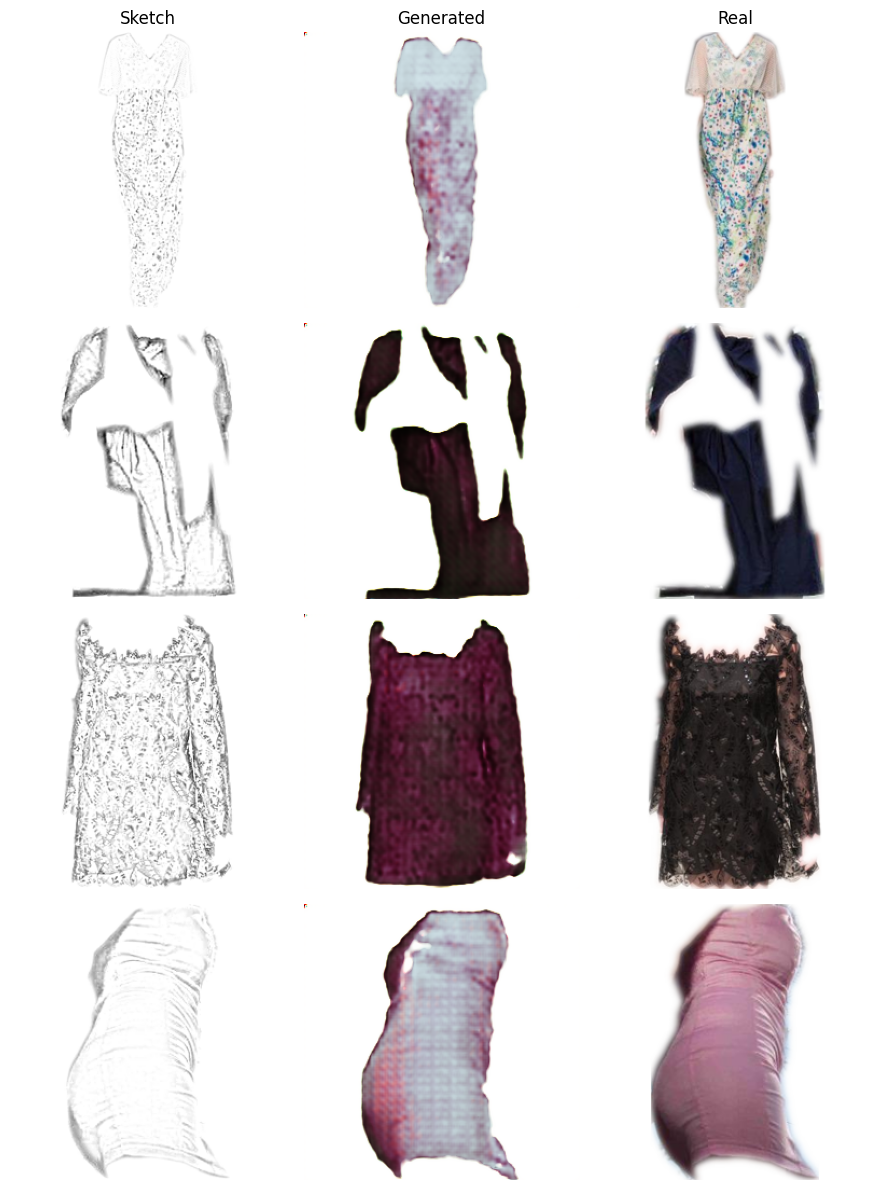

In [26]:
# Initialize model
# Using CycleGAN ResNet Generator configuration (resnet_9blocks)
generator = define_G(input_nc=3, output_nc=3, ngf=64, netG='resnet_9blocks', norm='instance', use_dropout=False, init_type='normal', init_gain=0.02).to(DEVICE)

# Path to your weights checkpoint (Update this path when running on Kaggle)
CHECKPOINT_PATH = '/kaggle/input/cyclegan-weights/last.pt'

# Load weights
try:
    load_generator_weights(CHECKPOINT_PATH, generator)
except FileNotFoundError:
    print(f"Warning: Checkpoint not found at {CHECKPOINT_PATH}. Model is initialized with random weights.")

# Run Evaluation
results = evaluate_model(generator, eval_loader, device=DEVICE)

# Show some generated samples
print("\nVisualizing some samples from evaluation set...")
generator.eval()
with torch.no_grad():
    batch = next(iter(eval_loader))
    sketch = batch['sketch'].to(DEVICE)
    real = batch['real'].to(DEVICE)
    fake = generator(sketch)
    
    save_sample_grid(sketch, fake, real, max_items=4)

In [ ]:
import time
import torch

# 1. Calculate parameters
total_params = sum(p.numel() for p in generator.parameters())
trainable_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)

# 2. Calculate FLOPs
dummy_sketch = torch.randn(1, 3, 256, 256, device=DEVICE)
flops_str = "FLOPs calculation     : Not available (please install fvcore or thop)"
try:
    from fvcore.nn import FlopCountAnalysis
    flops = FlopCountAnalysis(generator, dummy_sketch)
    flops_val = flops.total()
    flops_str = f"Total FLOPs           : {flops_val:,} ({flops_val/1e9:.2f} GFLOPs)"
except ImportError:
    try:
        import thop
        flops_val, _ = thop.profile(generator, inputs=(dummy_sketch,), verbose=False)
        flops_str = f"Total FLOPs           : {int(flops_val):,} ({flops_val/1e9:.2f} GFLOPs)"
    except ImportError:
        pass

print("="*50)
print("MODEL COMPLEXITY & INFERENCE SPEED EVALUATION")
print("="*50)
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(flops_str)

# 3. Measure inference speed
# Warm-up runs
generator.eval()
with torch.no_grad():
    for _ in range(20):
        _ = generator(dummy_sketch)

    # Sync before measuring
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
        
    start_time = time.perf_counter()
    num_runs = 100
    for _ in range(num_runs):
        _ = generator(dummy_sketch)
        
    # Sync after measuring
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
        
    end_time = time.perf_counter()

total_time = end_time - start_time
avg_time_ms = (total_time / num_runs) * 1000
fps = num_runs / total_time

print(f"Average Inference Time: {avg_time_ms:.2f} ms")
print(f"Inference FPS         : {fps:.2f} frames/sec")
print("="*50)